Clean notebook

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W1201 14:54:55.448124 140719953393472 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


## Load data

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/' # mag cut at 24.5 in r band
root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

## Load transformations of ellipticities

### for inputs

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

## Load models

### Loading directories

In [4]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v1 = root_dir_models+'v4/loss/'  # trained on sample with magnitude cut 24.5
dir_model_v2 = root_dir_models+'v1/loss/'  # trained on sample with magnitude cut 26.5

### Set models parameters

In [5]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

## Model v1 (training magnitude cut at 24.5 in $r$-band)

### Load data 

In [7]:
images = np.load(root_dir_v1+'img_sample.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_data.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity   = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)

e1 = ellipticity_conversion(ellipticity_1)
e2 = ellipticity_conversion(ellipticity_2)

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       10000 non-null float64
snr_r             9996 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9978 non-null float64
e2_hsm_regauss    9978 non-null float64
mag_r_meas        9996 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


### Load models

In [6]:
net_v1 = model.create_model_wo_ls_peak_3(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)  #create_model_wo_ls_peak_3
latest = tf.train.latest_checkpoint(dir_model_v1)
net_v1.load_weights(latest)

W1201 14:55:21.147616 140719953393472 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W1201 14:55:21.429709 140719953393472 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


In [25]:
img = np.zeros((1,59,59,6))
for i in range (6):
    img[:,:,:,i] = np.load('img.npy')

output_v1 = net_v1([tf.cast(img, tf.float32), tf.cast(psf[0], tf.float32)])

W1201 15:49:33.055087 140719953393472 network.py:847] Model was constructed with shape Tensor("input_2:0", shape=(?, 59, 59, 6), dtype=float32) for input (?, 59, 59, 6), but it was re-called on a Tensor with incompatible shape (59, 59, 6).


In [26]:
print(K.get_value(output_v1.mean())[:,0])
print(K.get_value(output_v1.mean())[:,1])

[-0.07382146]
[0.0294637]


In [8]:
nb_of_points = 1000
output_v1 = net_v1([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

Text(0.5, 1.0, '$e2$')

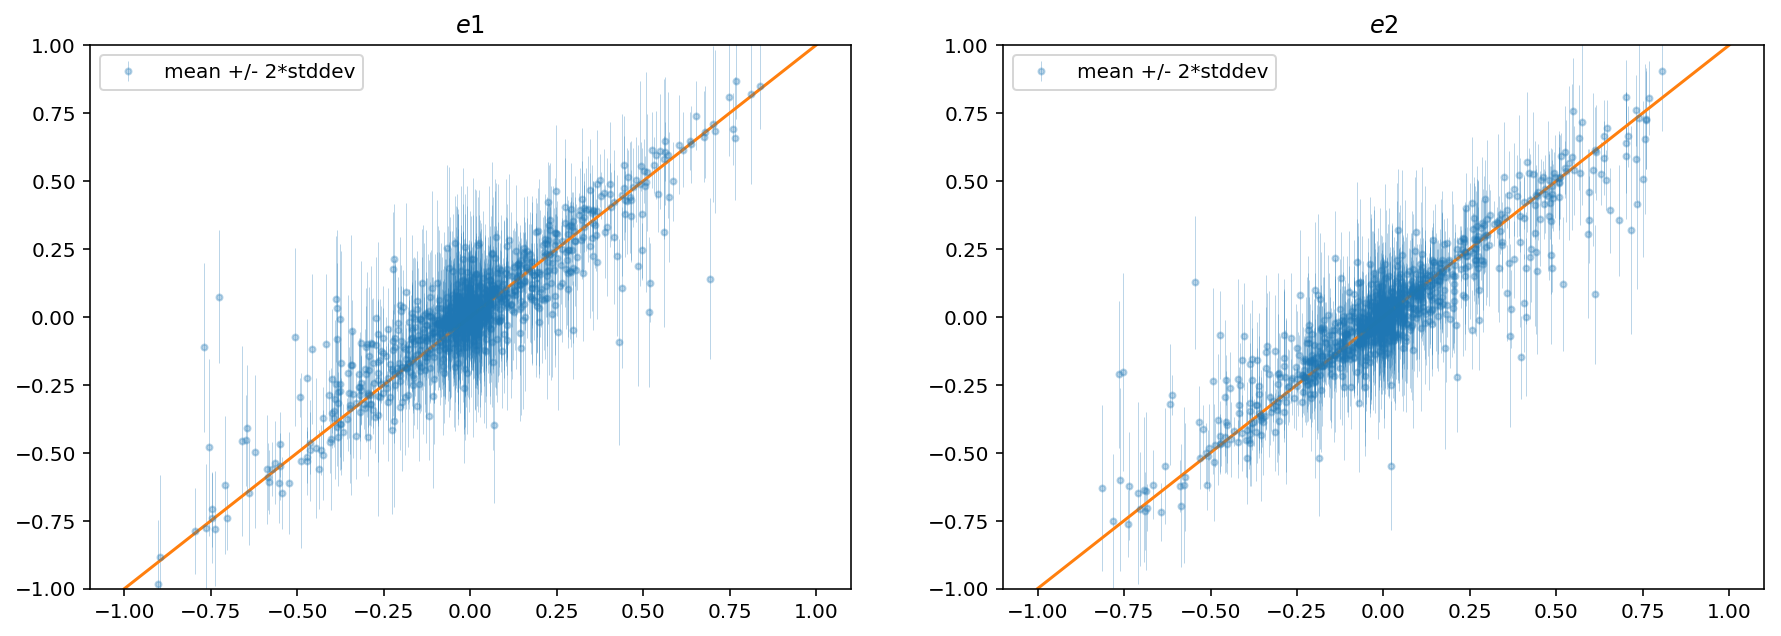

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2[:nb_of_points], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

Comparison with HSM measurement

In [10]:
diff_net_e1 = e1_out_mean + e1[:nb_of_points]
diff_net_e2 = e2_out_mean - e2[:nb_of_points]

diff_hsm_e1 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

Text(0, 0.5, 'ellipticity error (predict - true)')

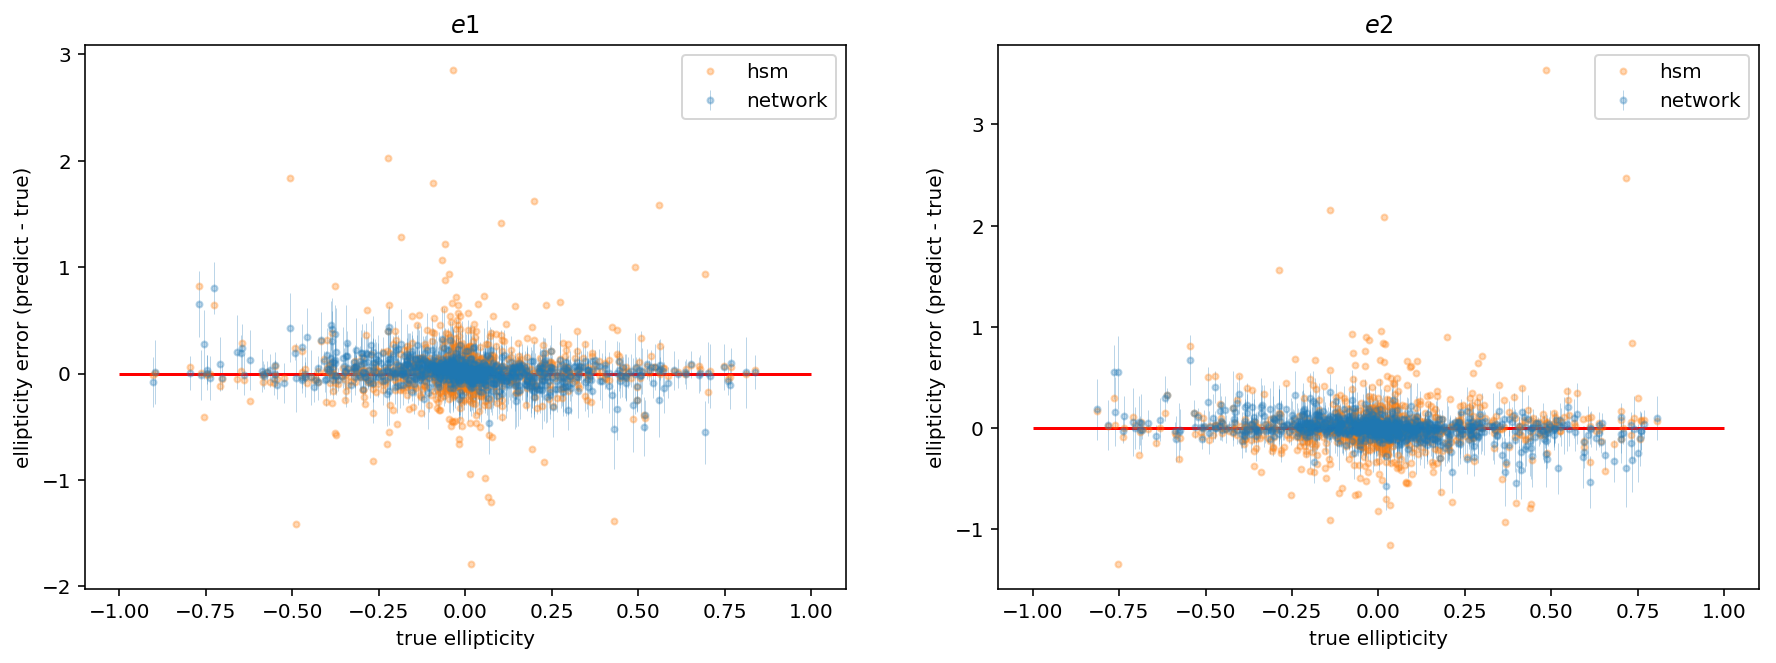

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')

(-1, 1)

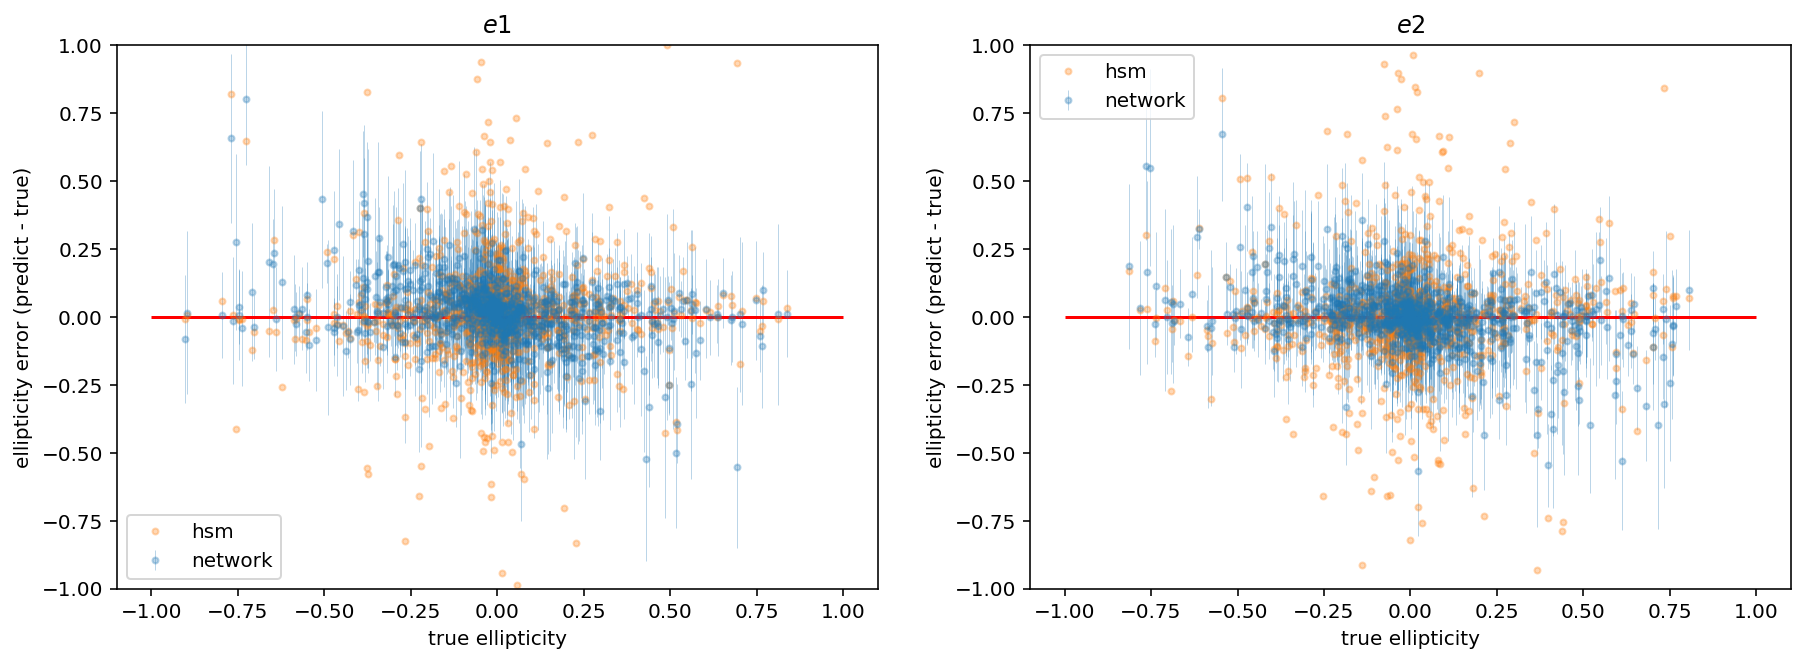

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')
axes[0].set_ylim(-1,1)

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')
axes[1].set_ylim(-1,1)

(-1, 1)

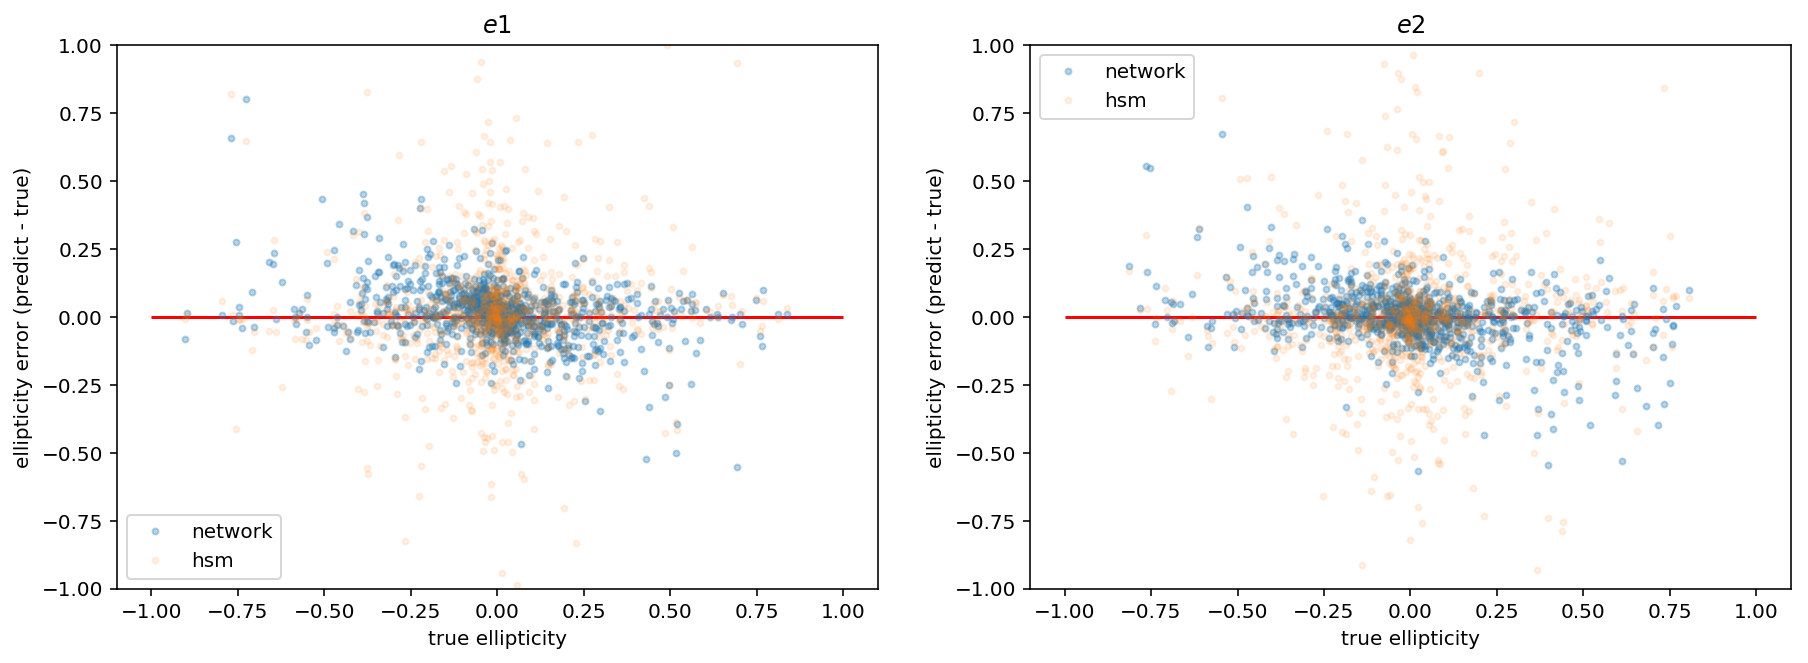

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].plot(-e1[:nb_of_points], diff_net_e1,'.', label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.1)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')
axes[0].set_ylim(-1,1)

axes[1].plot(e2[:nb_of_points], diff_net_e2, '.', label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.1)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')
axes[1].set_ylim(-1,1)

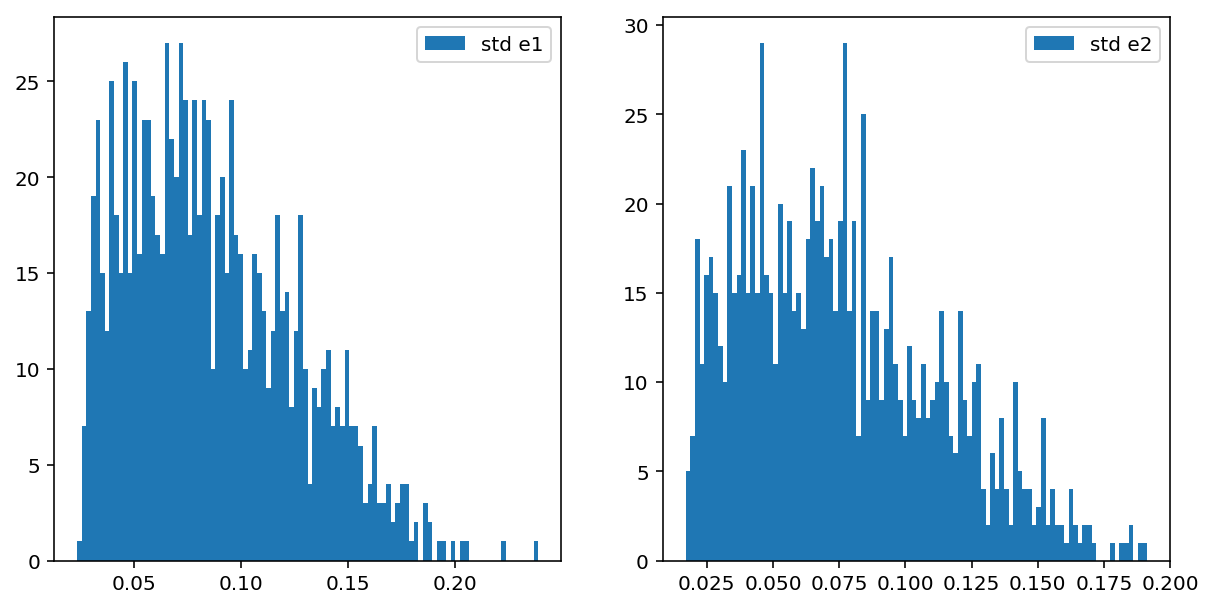

In [14]:
fig, ax = plt.subplots(1,2,figsize = (10,5))
_ = ax[0].hist(e1_out_std, bins = 100, label = 'std e1')
_ = ax[1].hist(e2_out_std, bins = 100, label = 'std e2')
ax[0].legend()
ax[1].legend()

## Model v2 (magnitude cut at 26.5 in $r$-band)

### Load data

In [15]:
images = np.load(root_dir_v2+'img_sample.npy', mmap_mode = 'c')
psf = np.load(root_dir_v2+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v2+'img_data.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity   = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)

e1 = ellipticity_conversion(ellipticity_1)
e2 = ellipticity_conversion(ellipticity_2)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
id                1000 non-null int64
e1                1000 non-null float64
e2                1000 non-null float64
shear_1           1000 non-null float64
shear_2           1000 non-null float64
redshift          1000 non-null float64
redshift_true     1000 non-null float64
blendedness       1000 non-null float64
snr_r             1000 non-null float64
convergence       1000 non-null float64
e1_hsm_regauss    879 non-null float64
e2_hsm_regauss    879 non-null float64
mag_r_meas        1000 non-null float64
mag_r_true        1000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 109.5 KB


### Load models

In [17]:
net_v2 = model.create_model_wo_ls_peak_3(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)  #create_model_wo_ls_peak_3
latest = tf.train.latest_checkpoint(dir_model_v2)
net_v2.load_weights(latest)

In [18]:
nb_of_points = 1000
output_v2 = net_v2([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean_v2 = K.get_value(output_v2.mean())[:,0]
e2_out_mean_v2 = K.get_value(output_v2.mean())[:,1]

e1_out_std_v2 = K.get_value(output_v2.stddev())[:,0]
e2_out_std_v2 = K.get_value(output_v2.stddev())[:,1]

In [19]:
diff_net_e1_v2 = e1_out_mean_v2 + e1[:nb_of_points]
diff_net_e2_v2 = e2_out_mean_v2 - e2[:nb_of_points]

diff_hsm_e1_v2 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2_v2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

(-1.5, 1.5)

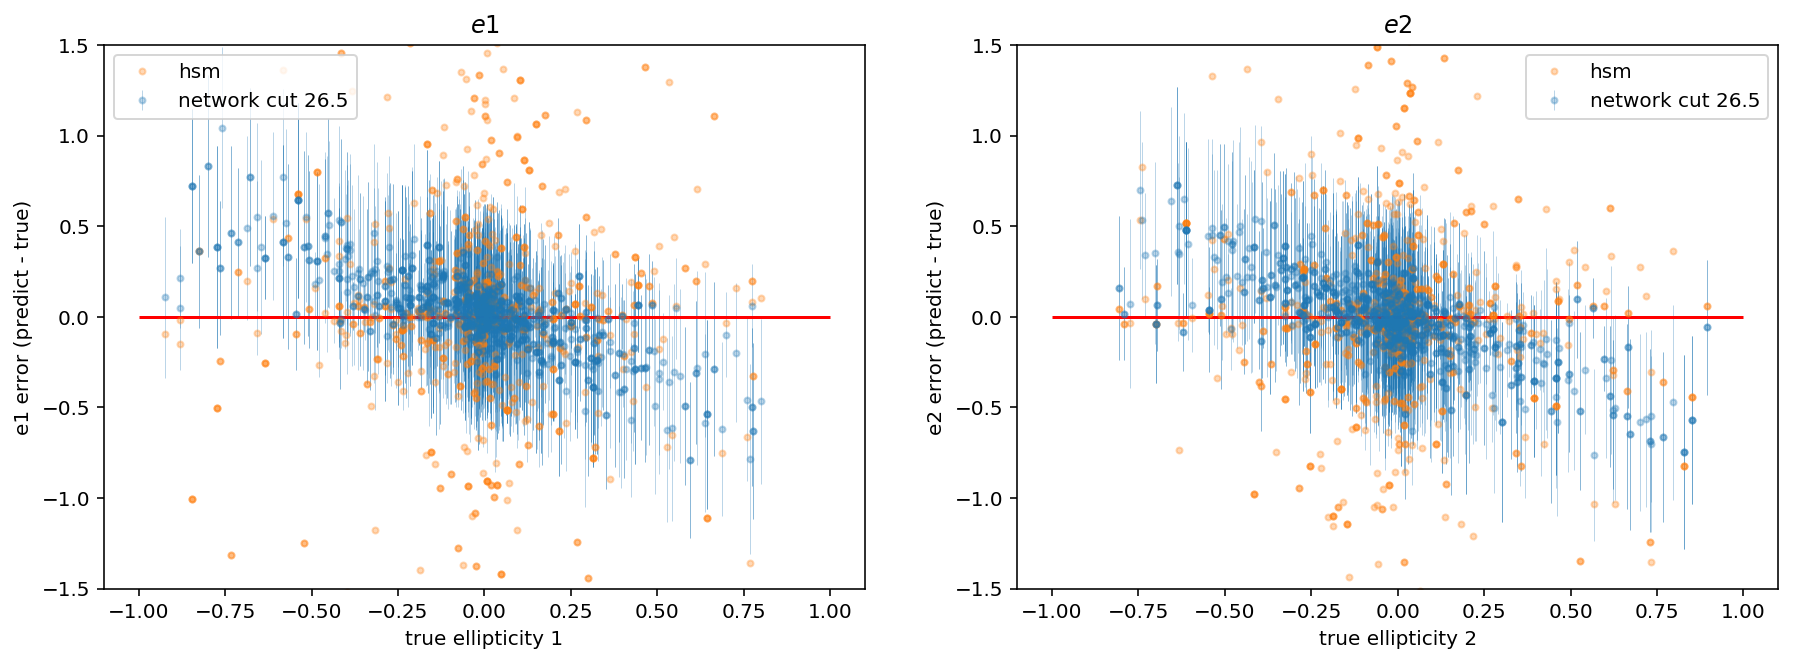

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1_v2, yerr = 2*e1_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1_v2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()
#axes[0].set_ylim(-0.2,0.2)
axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity 1')
axes[0].set_ylabel('e1 error (predict - true)')
axes[0].set_ylim(-1.5,1.5)

axes[1].errorbar(e2[:nb_of_points], diff_net_e2_v2, yerr = 2*e2_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2_v2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()
#nb_of_pointsaxes[1].set_ylim(-0.2,0.2)
axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity 2')
axes[1].set_ylabel('e2 error (predict - true)')
axes[1].set_ylim(-1.5,1.5)

## Comparison between the two cuts on 26.5 mag cut sample

In [21]:
# First let's test the model trained on 24.5 mag cut sample
nb_of_points = 1000
output_v1 = net_v1([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

diff_net_e1 = e1_out_mean + e1[:nb_of_points]
diff_net_e2 = e2_out_mean - e2[:nb_of_points]

diff_hsm_e1 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

Text(0, 0.5, 'e2 error (predict - true)')

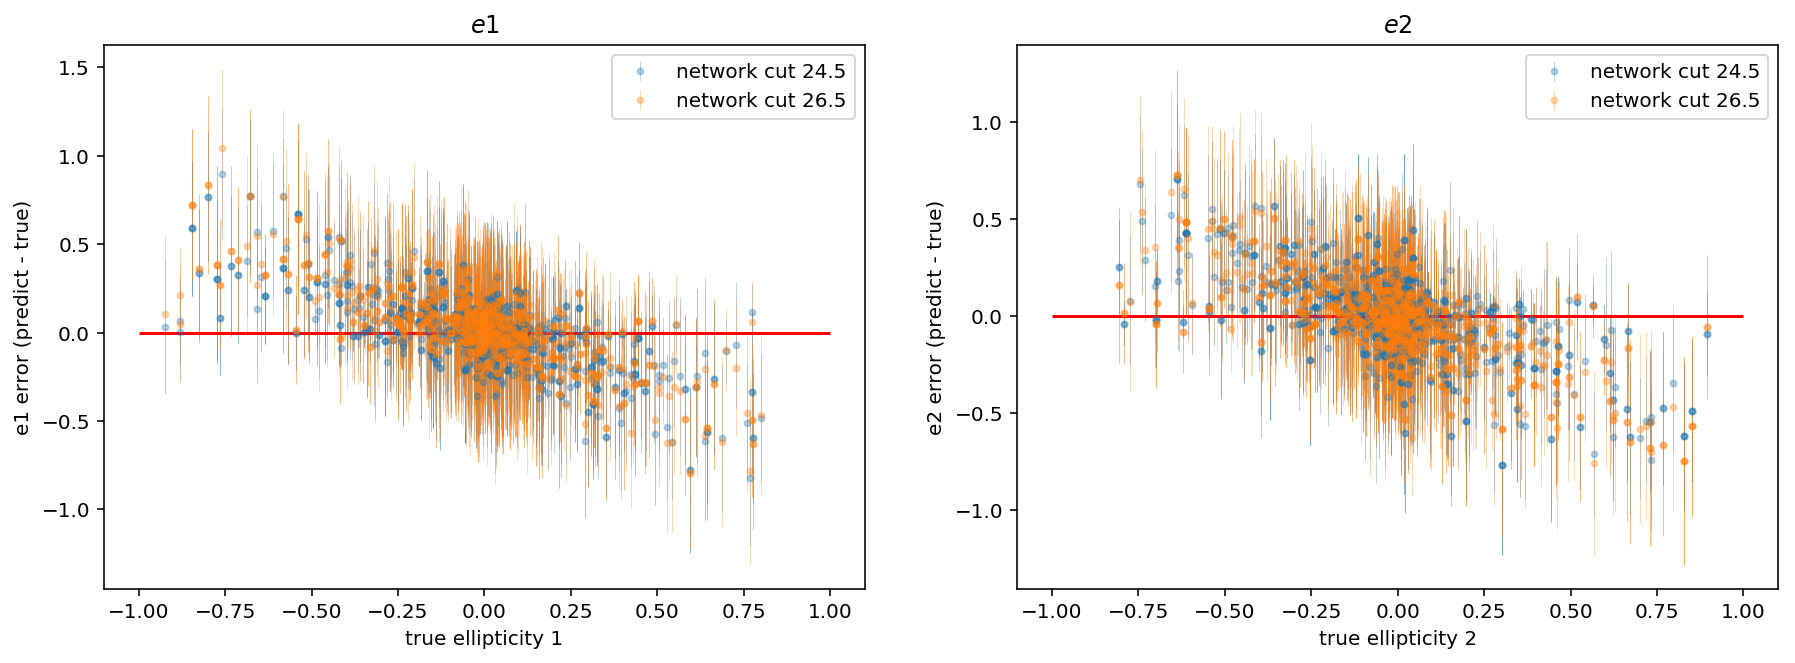

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network cut 24.5', alpha = 0.3)
axes[0].errorbar(-e1[:nb_of_points], diff_net_e1_v2, yerr = 2*e1_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()
axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity 1')
axes[0].set_ylabel('e1 error (predict - true)')

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network cut 24.5', alpha = 0.3)
axes[1].errorbar(e2[:nb_of_points], diff_net_e2_v2, yerr = 2*e2_out_std_v2,  fmt='.', elinewidth=0.5, label = 'network cut 26.5', alpha = 0.3)

x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()
axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity 2')
axes[1].set_ylabel('e2 error (predict - true)')

Merge two dictionnaries

In [23]:
df_plot = pd.DataFrame()

df_v1 = pd.read_csv(root_dir_v1+'img_data.csv')
df_v2 = pd.read_csv(root_dir_v2+'img_data.csv')

df_plot = pd.concat([df_v2[:nb_of_points], df_v2[:nb_of_points]], ignore_index=True, sort = True)
df_plot['e1_error'] = np.concatenate([diff_net_e1,diff_net_e1_v2])
df_plot['e2_error'] = np.concatenate([diff_net_e2,diff_net_e2_v2])
df_plot['exp'] = [1]*nb_of_points + [2]*nb_of_points

In [24]:
df_plot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
blendedness       2000 non-null float64
convergence       2000 non-null float64
e1                2000 non-null float64
e1_hsm_regauss    1758 non-null float64
e2                2000 non-null float64
e2_hsm_regauss    1758 non-null float64
id                2000 non-null int64
mag_r_meas        2000 non-null float64
mag_r_true        2000 non-null float64
redshift          2000 non-null float64
redshift_true     2000 non-null float64
shear_1           2000 non-null float64
shear_2           2000 non-null float64
snr_r             2000 non-null float64
e1_error          2000 non-null float64
e2_error          2000 non-null float64
exp               2000 non-null int64
dtypes: float64(15), int64(2)
memory usage: 265.7 KB


In [25]:
np.min(df_plot['mag_r_true'])

19.75494795468652

1758
[1 2]
0 1
1 2


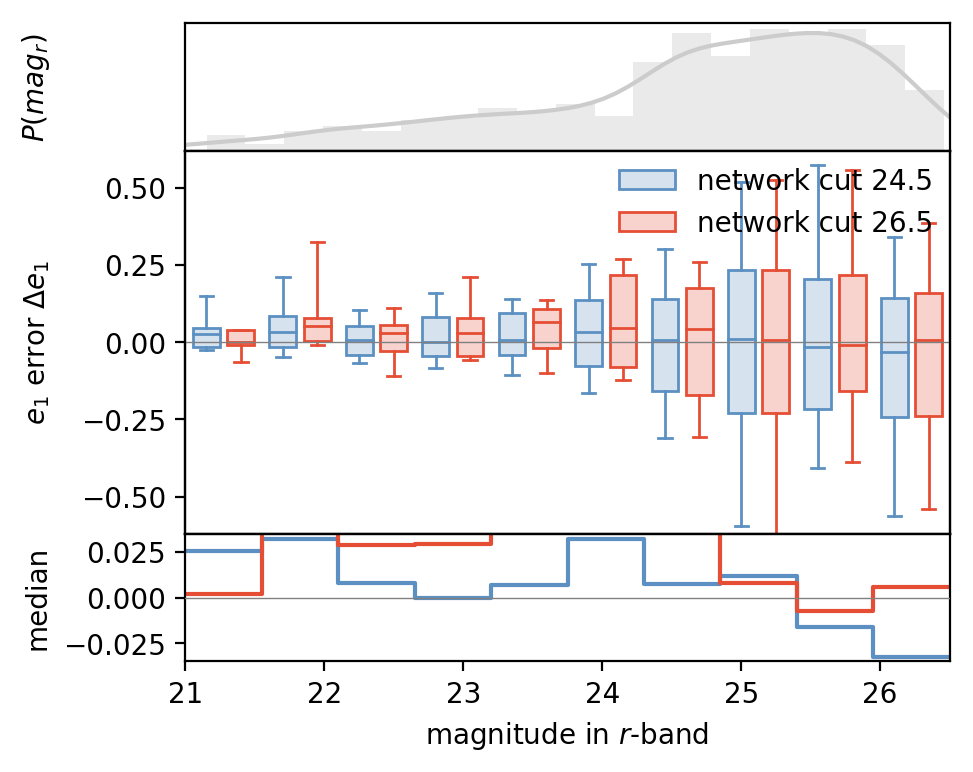

In [26]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot, 
              x = 'mag_r_true', y = 'e1_error', z = 'exp',
              xlim = (21, 26.5),
              ylim = (-0.62, 0.62), 
              ylim2 = (-0.035, 0.035), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'network cut 26.5'],
              x_label='magnitude in $r$-band', 
              y_label = '$e_1$ error $\\Delta e_1$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

1758
[1 2]
0 1
1 2


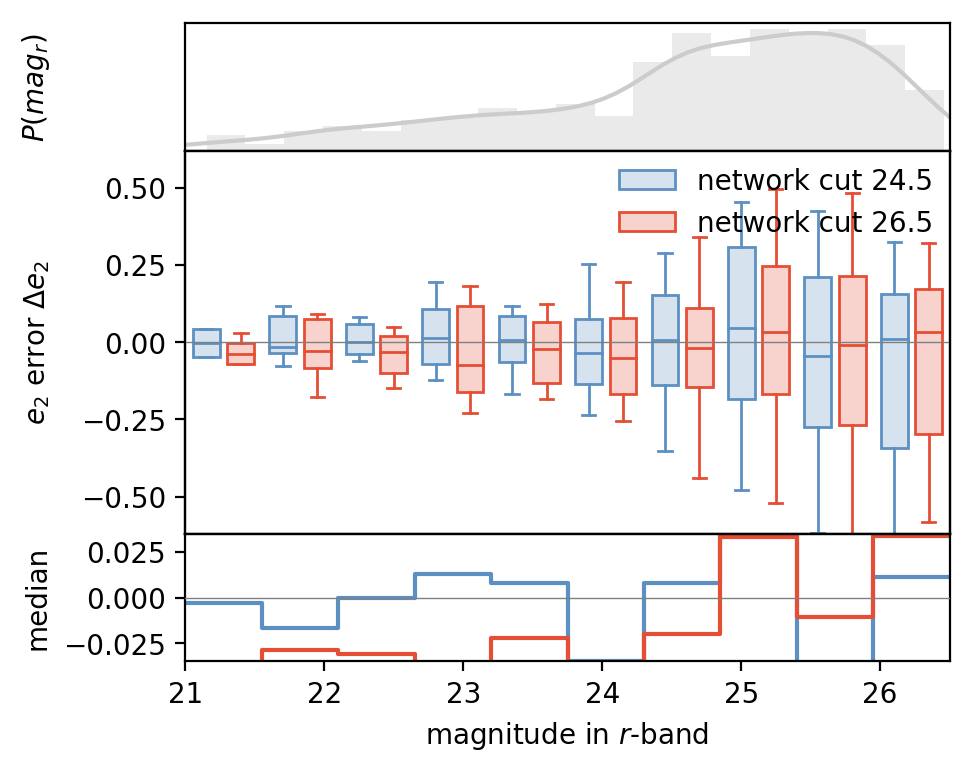

In [27]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot, 
              x = 'mag_r_true', y = 'e2_error', z = 'exp',
              xlim = (21, 26.5),
              ylim = (-0.62, 0.62), 
              ylim2 = (-0.035, 0.035), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'network cut 26.5'],
              x_label='magnitude in $r$-band', 
              y_label = '$e_2$ error $\\Delta e_2$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

Compare with HSM

In [28]:
df_plot_hsm = pd.DataFrame()

df_v1 = pd.read_csv(root_dir_v1+'img_data.csv')
df_v2 = pd.read_csv(root_dir_v2+'img_data.csv')

df_plot_hsm = pd.concat([df_v2[:nb_of_points], df_v2[:nb_of_points],df_v2[:nb_of_points], df_v2[:nb_of_points]], ignore_index=True, sort = True)
df_plot_hsm['e1_error'] = np.concatenate([diff_net_e1,diff_net_e1_v2, diff_hsm_e1, diff_hsm_e1_v2])
df_plot_hsm['e2_error'] = np.concatenate([diff_net_e2,diff_net_e2_v2, diff_hsm_e2, diff_hsm_e2_v2])
df_plot_hsm['exp'] = [1]*nb_of_points + [2]*nb_of_points + [3]*2*nb_of_points

3516
[1 2 3]
0 1
1 2
2 3


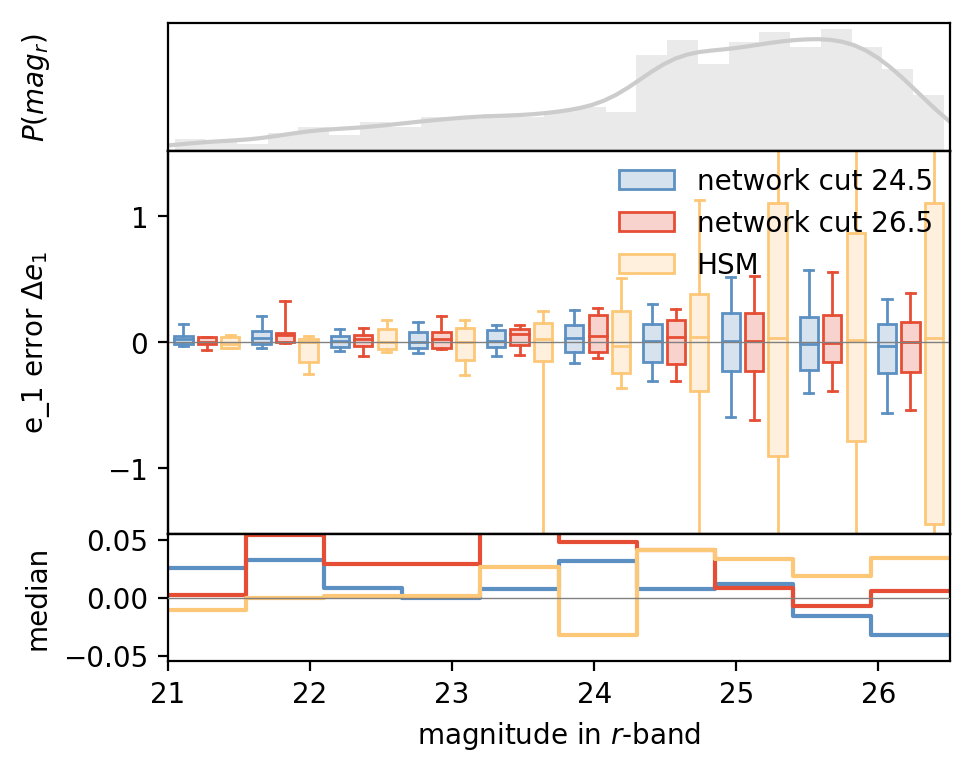

In [29]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_hsm, 
              x = 'mag_r_true', y = 'e1_error', z = 'exp',
              xlim = (21, 26.5),
              ylim = (-1.52, 1.52), 
              ylim2 = (-0.055, 0.055), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='magnitude in $r$-band', 
              y_label = 'e_1 error $\\Delta e_1$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)

3516
[1 2 3]
0 1
1 2
2 3


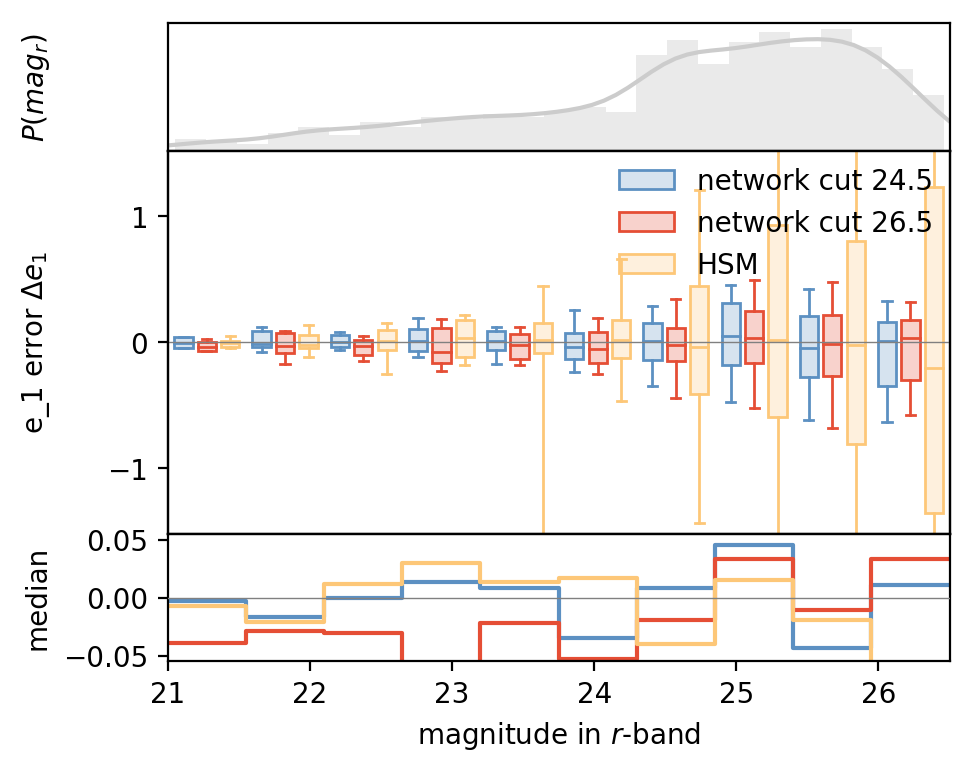

In [30]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_hsm, 
              x = 'mag_r_true', y = 'e2_error', z = 'exp',
              xlim = (21, 26.5),
              ylim = (-1.52, 1.52), 
              ylim2 = (-0.055, 0.055), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='magnitude in $r$-band', 
              y_label = 'e_1 error $\\Delta e_1$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)

## Which images are problematic

### For HSM

In [31]:
lim = 0.3

pb_idx = np.where((diff_hsm_e1_v2>lim) | (diff_hsm_e1_v2<-lim) | (diff_hsm_e2_v2>lim) | (diff_hsm_e2_v2<-lim))[0]

In [32]:
print(len(pb_idx))
print(pb_idx)

545
[  0   1   4   5  10  12  13  14  15  18  19  21  23  24  25  30  34  35
  36  38  41  42  43  44  46  48  50  51  52  54  55  60  61  62  65  68
  69  70  74  76  77  78  79  80  81  84  85  88  89  90  93  96  97  98
  99 100 102 103 104 106 110 112 115 116 117 118 119 124 127 129 130 131
 132 133 134 136 137 140 141 142 143 144 145 146 148 150 156 158 159 162
 163 164 167 169 172 173 174 175 177 178 179 180 181 182 183 185 188 191
 192 194 195 198 199 204 205 208 213 214 216 217 219 222 225 226 227 230
 233 234 237 239 240 244 245 246 247 248 249 251 252 254 256 258 260 263
 264 266 268 270 271 272 273 275 276 277 283 288 289 290 291 292 294 295
 297 298 302 303 304 305 310 312 313 314 315 316 317 318 319 320 321 322
 323 324 325 326 328 329 331 332 334 335 336 338 341 342 345 347 349 350
 353 354 355 356 358 360 361 362 364 365 367 369 370 373 376 377 379 380
 381 383 384 386 387 389 393 394 395 397 398 399 400 401 403 404 406 407
 411 412 413 414 415 419 420 422 425 427 428 42

Is there a higher mean blendedness for the images problematic for HSM REGAUSS method ?

In [33]:
print('mean blendedness of sample with high error: '+str(np.mean((data['blendedness'][pb_idx],data['blendedness'][pb_idx]))))
print('mean blendedness of whole sample: '+str(np.mean(data['blendedness'])))

mean blendedness of sample with high error: 0.03544586698114315
mean blendedness of whole sample: 0.027828054176799163


This difference might partially explain the gap between our method and HSM REGAUSS

Let's check other possibilities (mag, redshift, snr... ?)

In [34]:
# Magnitudes
print('mean magnitudes of sample with high error: '+str(np.mean((data['mag_r_meas'][pb_idx],data['mag_r_meas'][pb_idx]))))
print('mean magnitudes of whole sample: '+str(np.mean(data['mag_r_meas'])))

mean magnitudes of sample with high error: 25.30907042900967
mean magnitudes of whole sample: 24.77765395392593


In [35]:
# SNR
print('mean SNR of sample with high error: '+str(np.mean((data['snr_r'][pb_idx],data['snr_r'][pb_idx]))))
print('mean SNR of whole sample: '+str(np.mean(data['snr_r'])))

mean SNR of sample with high error: 21.226342629764627
mean SNR of whole sample: 57.4413107221645


In [36]:
# redshift
print('mean redshift of sample with high error: '+str(np.mean((data['redshift'][pb_idx],data['redshift'][pb_idx]))))
print('mean redshift of whole sample: '+str(np.mean(data['redshift'])))

mean redshift of sample with high error: 1.0934518914575428
mean redshift of whole sample: 0.9969920787568749


Higher magnitude and reshift, and consequently lower SNR seem to be also an aggraving factor for HSM REGAUSS

Let's plot some of these images

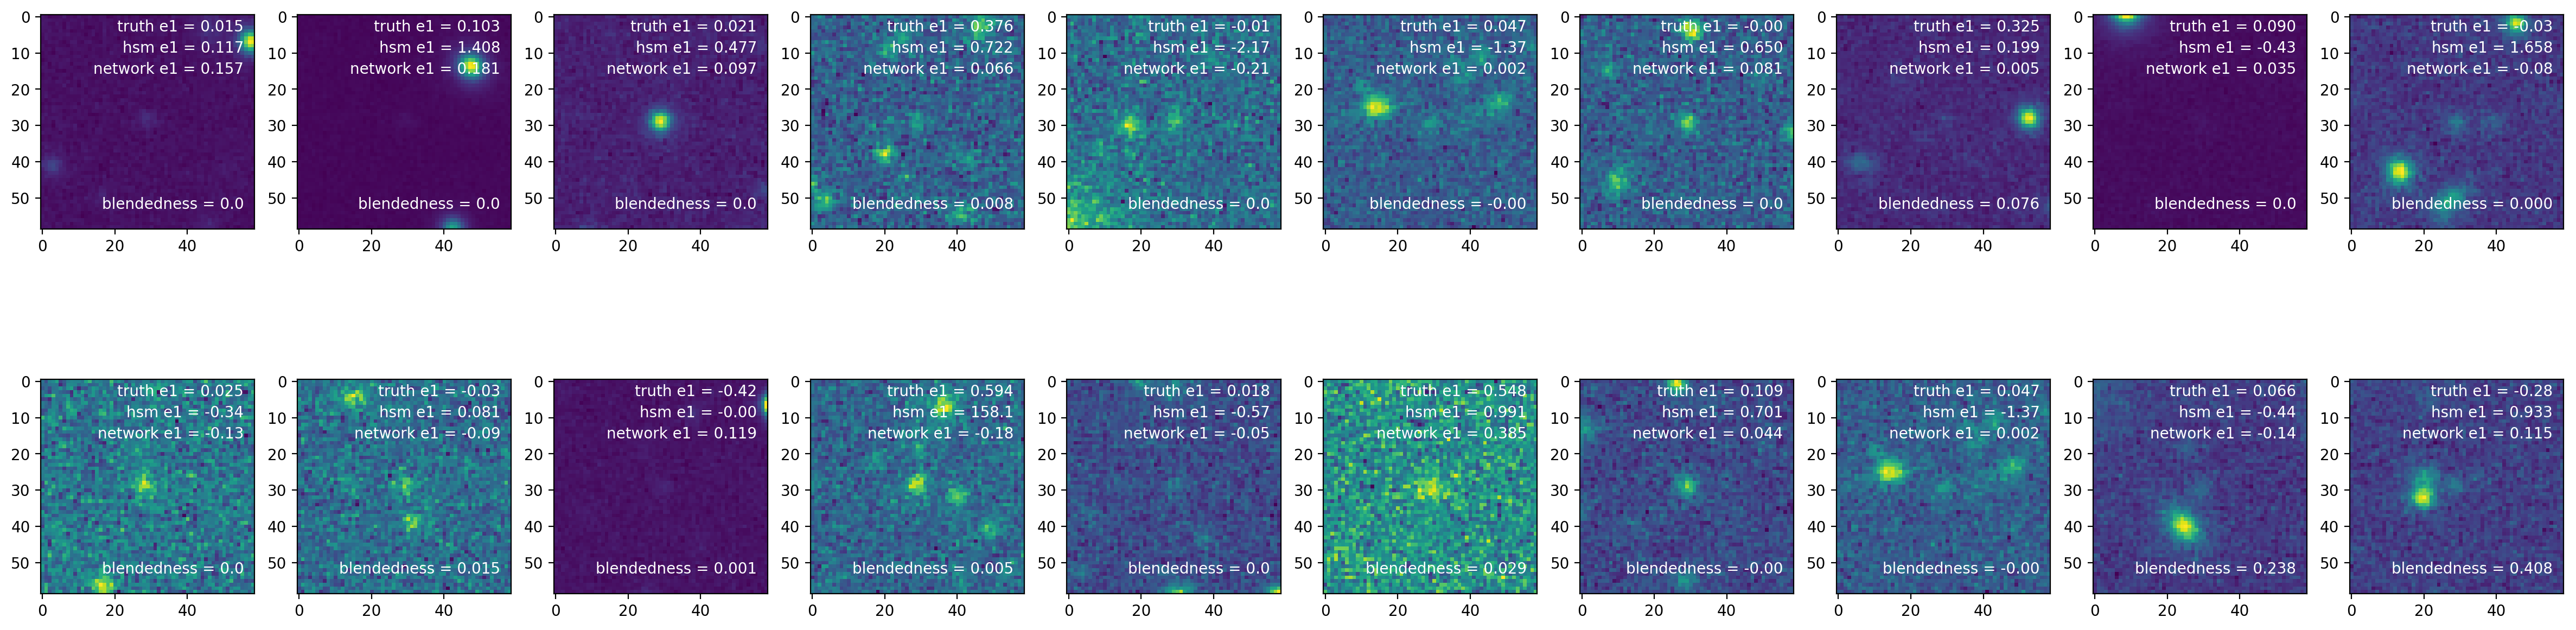

In [37]:
fig, axes = plt.subplots(2, 10, figsize=(30,8))
left, width = .15, .80
bottom, height = .15, .83
right = left + width
top = bottom + height

for i in range(2):
    for j in range (10):
        k = np.random.choice(pb_idx)
        axes[i,j].imshow(images[k,:,:,2])
        axes[i,j].text(right, top, 'truth e1 = '+str(-e1[k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)
        axes[i,j].text(right, top-0.1, 'hsm e1 = '+str(data['e1_hsm_regauss'][k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)
        axes[i,j].text(right, top-0.2, 'network e1 = '+str(e1_out_mean[k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)
        axes[i,j].text(right, bottom, 'blendedness = '+str(data['blendedness'][k])[:5], horizontalalignment='right', verticalalignment='top', color = 'white', transform=axes[i,j].transAxes)

Now let's see how our network behaves on these particular cases compared to HSM

In [38]:
print('mean error e1 for HSM: '+str(np.mean(diff_hsm_e1_v2[pb_idx])))
print('mean error e1 for network: '+str(np.mean(diff_net_e1[pb_idx])))

print('mean error e2 for HSM: '+str(np.mean(diff_hsm_e2_v2[pb_idx])))
print('mean error e2 for network: '+str(np.mean(diff_net_e2[pb_idx])))

mean error e1 for HSM: 0.4589707054948568
mean error e1 for network: -0.0027480498331201833
mean error e2 for HSM: -0.4219994519447439
mean error e2 for network: -0.006379760378645515


### For our methods

In [39]:
lim = 0.3

pb_idx_net = np.where((diff_net_e1>lim) | (diff_net_e1<-lim) | (diff_net_e2>lim) | (diff_net_e2<-lim))[0]
pb_idx_net_v2 = np.where((diff_net_e1_v2>lim) | (diff_net_e1_v2<-lim) | (diff_net_e2_v2>lim) | (diff_net_e2_v2<-lim))[0]

In [40]:
pb_idx_net

array([  0,   2,  10,  11,  13,  14,  19,  22,  25,  26,  32,  38,  41,
        43,  44,  48,  55,  60,  61,  62,  65,  67,  69,  81,  84,  87,
        98, 100, 106, 107, 110, 112, 116, 117, 139, 142, 145, 160, 164,
       166, 168, 172, 185, 192, 197, 205, 208, 210, 212, 216, 217, 218,
       227, 229, 232, 239, 248, 252, 264, 266, 270, 283, 288, 291, 292,
       295, 311, 316, 319, 322, 325, 331, 334, 336, 339, 341, 344, 346,
       347, 349, 350, 356, 357, 358, 364, 365, 373, 379, 380, 381, 383,
       384, 389, 390, 396, 397, 398, 401, 403, 413, 414, 415, 422, 426,
       439, 442, 447, 455, 464, 469, 473, 479, 498, 501, 504, 512, 514,
       518, 519, 521, 524, 526, 529, 545, 546, 548, 550, 551, 553, 564,
       565, 580, 595, 596, 606, 613, 615, 617, 634, 637, 643, 647, 660,
       674, 677, 679, 680, 683, 684, 688, 689, 697, 705, 707, 710, 720,
       721, 724, 727, 729, 730, 731, 735, 737, 738, 743, 748, 753, 755,
       756, 758, 759, 760, 762, 768, 769, 770, 777, 783, 786, 79

In [41]:
pb_idx_net_v2

array([ 10,  11,  12,  13,  14,  19,  22,  25,  26,  32,  41,  43,  44,
        48,  50,  52,  55,  62,  65,  67,  69,  81,  84,  87,  89,  98,
        99, 100, 107, 110, 112, 116, 127, 139, 142, 143, 145, 160, 164,
       166, 168, 172, 182, 185, 186, 192, 197, 205, 208, 210, 212, 217,
       218, 225, 227, 237, 239, 248, 250, 252, 256, 264, 266, 270, 278,
       283, 288, 291, 292, 294, 295, 311, 316, 319, 322, 331, 334, 341,
       344, 347, 352, 356, 358, 364, 365, 373, 379, 380, 381, 383, 389,
       390, 396, 397, 398, 401, 403, 413, 414, 415, 426, 428, 439, 442,
       453, 455, 456, 464, 472, 473, 477, 479, 488, 491, 498, 504, 509,
       512, 514, 519, 521, 524, 526, 529, 548, 550, 564, 565, 580, 587,
       589, 595, 596, 600, 606, 613, 617, 619, 629, 634, 643, 649, 660,
       673, 674, 677, 679, 683, 684, 688, 689, 697, 698, 707, 710, 720,
       721, 727, 729, 730, 731, 735, 736, 743, 747, 748, 753, 755, 756,
       758, 759, 760, 762, 768, 770, 777, 783, 786, 792, 795, 80

For network trained on sample with cut at 24.5 in $r$ magnitude

In [42]:
# Blendedness
print('mean blendedness of sample with high error: '+str(np.mean((data['blendedness'][pb_idx_net],data['blendedness'][pb_idx_net]))))
print('mean blendedness of whole sample: '+str(np.mean(data['blendedness'])))

# Magnitudes
print('mean magnitudes of sample with high error: '+str(np.mean((data['mag_r_meas'][pb_idx_net],data['mag_r_meas'][pb_idx_net]))))
print('mean magnitudes of whole sample: '+str(np.mean(data['mag_r_meas'])))

# SNR
print('mean SNR of sample with high error: '+str(np.mean((data['snr_r'][pb_idx_net],data['snr_r'][pb_idx_net]))))
print('mean SNR of whole sample: '+str(np.mean(data['snr_r'])))

# redshift
print('mean redshift of sample with high error: '+str(np.mean((data['redshift'][pb_idx_net],data['redshift'][pb_idx_net]))))
print('mean redshift of whole sample: '+str(np.mean(data['redshift'])))

mean blendedness of sample with high error: 0.027200766742323305
mean blendedness of whole sample: 0.027828054176799163
mean magnitudes of sample with high error: 25.57154996274886
mean magnitudes of whole sample: 24.77765395392593
mean SNR of sample with high error: 16.089095301333888
mean SNR of whole sample: 57.4413107221645
mean redshift of sample with high error: 0.9892801216326507
mean redshift of whole sample: 0.9969920787568749


For network trained on sample with cut at 26.5 in $r$ magnitude

In [43]:
# Blendedness
print('mean blendedness of sample with high error: '+str(np.mean((data['blendedness'][pb_idx_net_v2],data['blendedness'][pb_idx_net_v2]))))
print('mean blendedness of whole sample: '+str(np.mean(data['blendedness'])))

# Magnitudes
print('mean magnitudes of sample with high error: '+str(np.mean((data['mag_r_meas'][pb_idx_net_v2],data['mag_r_meas'][pb_idx_net_v2]))))
print('mean magnitudes of whole sample: '+str(np.mean(data['mag_r_meas'])))

# SNR
print('mean SNR of sample with high error: '+str(np.mean((data['snr_r'][pb_idx_net_v2],data['snr_r'][pb_idx_net_v2]))))
print('mean SNR of whole sample: '+str(np.mean(data['snr_r'])))

# redshift
print('mean redshift of sample with high error: '+str(np.mean((data['redshift'][pb_idx_net_v2],data['redshift'][pb_idx_net_v2]))))
print('mean redshift of whole sample: '+str(np.mean(data['redshift'])))

mean blendedness of sample with high error: 0.026983207302461305
mean blendedness of whole sample: 0.027828054176799163
mean magnitudes of sample with high error: 25.462217888528503
mean magnitudes of whole sample: 24.77765395392593
mean SNR of sample with high error: 20.772931366757284
mean SNR of whole sample: 57.4413107221645
mean redshift of sample with high error: 0.9657461272600311
mean redshift of whole sample: 0.9969920787568749


<b>It seems that the networks yield slightly more blendedness-agnostic results (to be confirmed). Also our methods find the task to be hard at lower SNR than HSM. </b>

### Correlation between object ellipticity and PSF ellipticity ? (ellipticity bias)

#### With network trained on sample with mag cut at 26.5

In [44]:
nb_of_points = 1000
output_v2 = net_v2([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean_v2 = K.get_value(output_v2.mean())[:,0]
e2_out_mean_v2 = K.get_value(output_v2.mean())[:,1]

e1_out_std_v2 = K.get_value(output_v2.stddev())[:,0]
e2_out_std_v2 = K.get_value(output_v2.stddev())[:,1]

In [45]:
nb_of_points = 1000
output_v2 = net_v2([tf.cast(psf[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean_psf = K.get_value(output_v2.mean())[:,0]
e2_out_mean_psf = K.get_value(output_v2.mean())[:,1]

e1_out_std_psf = K.get_value(output_v2.stddev())[:,0]
e2_out_std_psf = K.get_value(output_v2.stddev())[:,1]

In [46]:
df = pd.DataFrame()
df['e1_net'] = e1_out_mean_v2
df['e2_net'] = e2_out_mean_v2
df['e1_psf'] = e1_out_mean_psf
df['e2_psf'] = e2_out_mean_psf

df.corr()

,e1_net,e2_net,e1_psf,e2_psf
e1_net,1.000000,0.000813,-0.013369,0.007463
e2_net,0.000813,1.000000,0.059390,0.062374
e1_psf,-0.013369,0.059390,1.000000,0.593762
e2_psf,0.007463,0.062374,0.593762,1.000000


In [47]:
len(df)

1000

In [57]:
len(df[(df['e1_psf']<-0.015)])

999

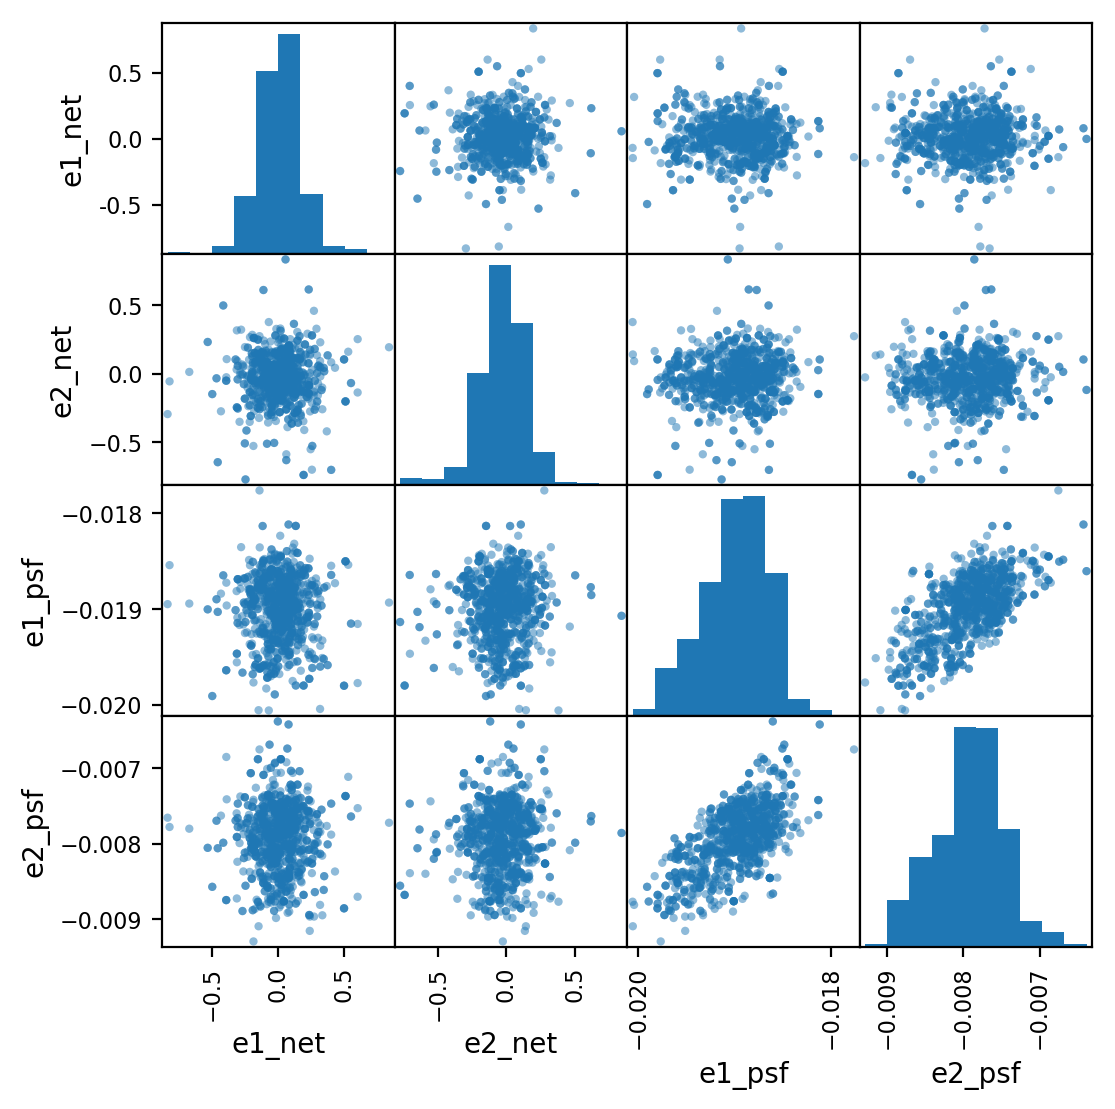

In [58]:
_ = pd.plotting.scatter_matrix(df[(df['e1_psf']<-0.015)], figsize=(6, 6))

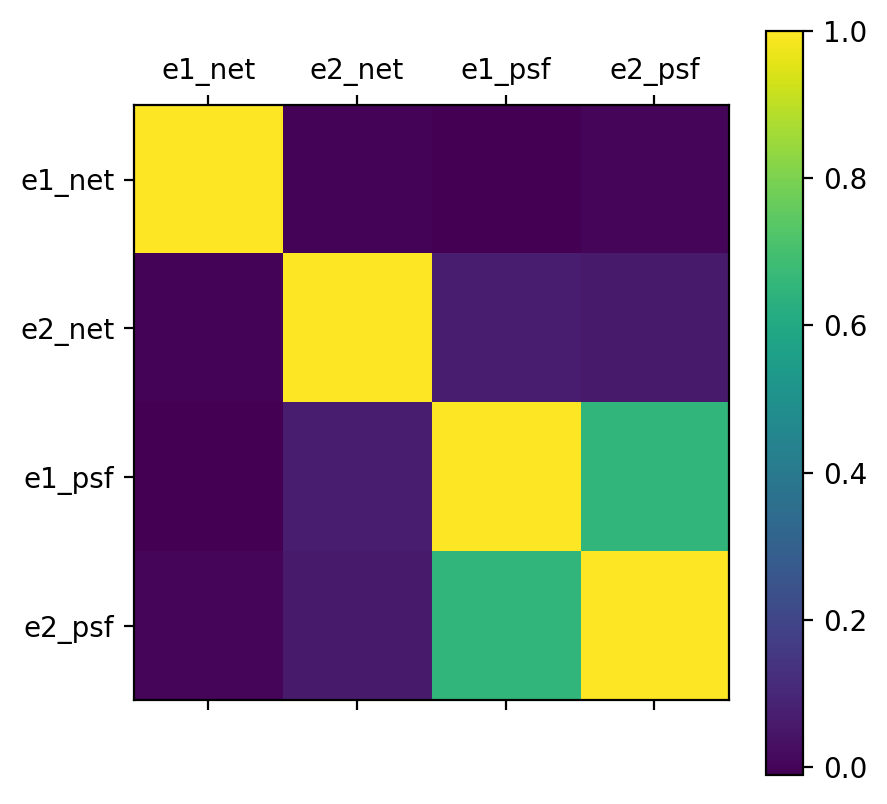

In [59]:
plt.matshow(df[(df['e1_psf']<-0.015)].corr())
plt.xticks(range(len(df.columns)), df.columns)
plt.yticks(range(len(df.columns)), df.columns)
plt.colorbar()
plt.show()

### Noise bias

In [60]:
df_plot_hsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
blendedness       4000 non-null float64
convergence       4000 non-null float64
e1                4000 non-null float64
e1_hsm_regauss    3516 non-null float64
e2                4000 non-null float64
e2_hsm_regauss    3516 non-null float64
id                4000 non-null int64
mag_r_meas        4000 non-null float64
mag_r_true        4000 non-null float64
redshift          4000 non-null float64
redshift_true     4000 non-null float64
shear_1           4000 non-null float64
shear_2           4000 non-null float64
snr_r             4000 non-null float64
e1_error          3758 non-null float64
e2_error          3758 non-null float64
exp               4000 non-null int64
dtypes: float64(15), int64(2)
memory usage: 531.3 KB


3516
[1 2 3]
0 1
1 2
2 3


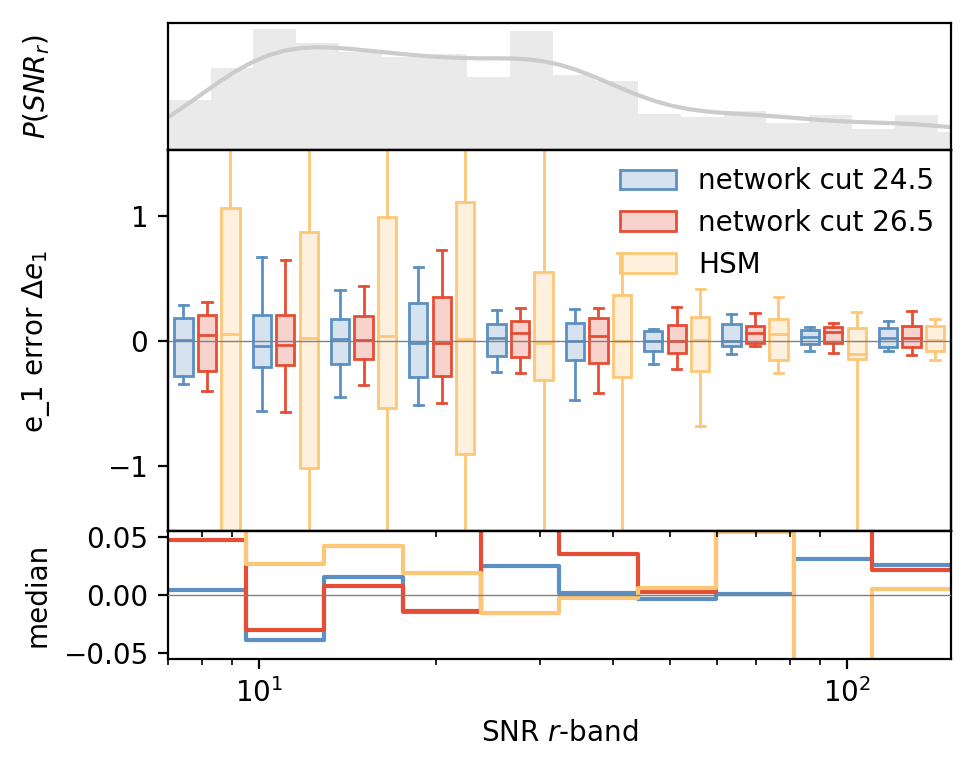

In [61]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_hsm, 
              x = 'snr_r', y = 'e1_error', z = 'exp',
              xlim = (7, 150),
              ylim = (-1.52, 1.52), 
              ylim2 = (-0.055, 0.055), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = 'e_1 error $\\Delta e_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)

3516
[1 2 3]
0 1
1 2
2 3


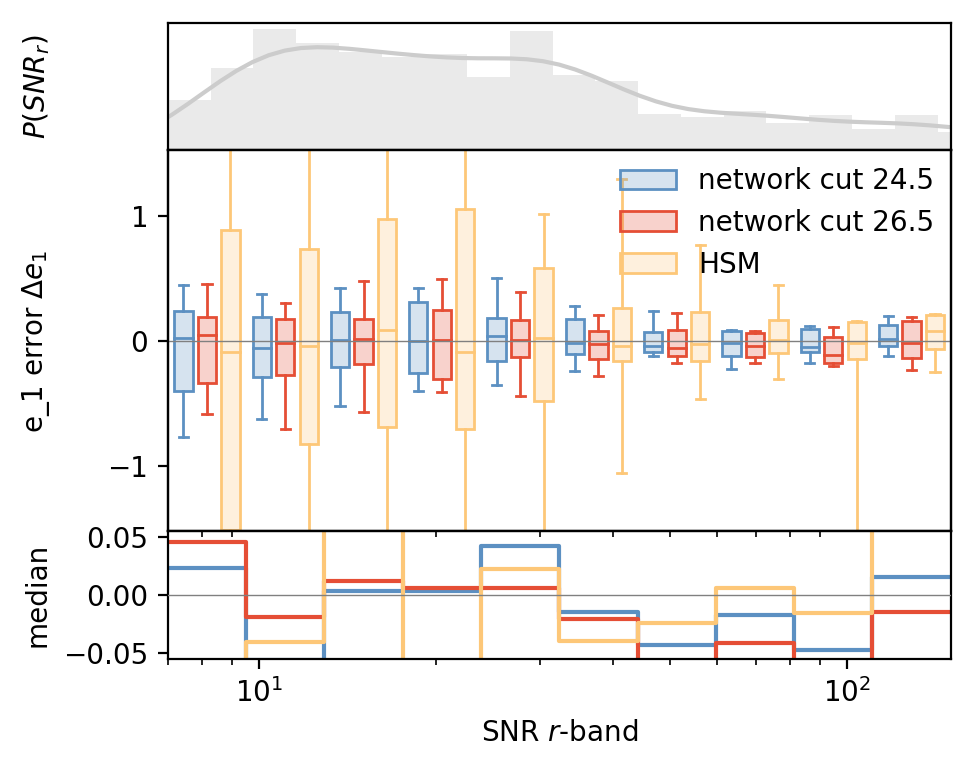

In [62]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_hsm, 
              x = 'snr_r', y = 'e2_error', z = 'exp',
              xlim = (7, 150),
              ylim = (-1.52, 1.52), 
              ylim2 = (-0.055, 0.055), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = 'e_1 error $\\Delta e_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)

### Model bias (??)

In [63]:
print('mean e1 from true catalog: '+str(np.mean(e1))+' and mean e2 from true catalog: '+str(np.mean(e2)))
print('mean e1 for model 1: '+str(np.mean(e1_out_mean))+' and mean e2 for model 1: '+str(np.mean(e2_out_mean)))
print('mean e1 for model 2: '+str(np.mean(e1_out_mean_v2))+' and mean e2 for model 2: '+str(np.mean(e2_out_mean_v2)))
print('mean e1 for HSM: '+str(np.mean(data['e1_hsm_regauss'][:nb_of_points]))+' and mean e2 for HSM: '+str(np.mean(data['e2_hsm_regauss'][:nb_of_points])))

mean e1 from true catalog: 0.013016421804584406 and mean e2 from true catalog: -0.018066227085653835
mean e1 for model 1: -0.006931509 and mean e2 for model 1: -0.021384614
mean e1 for model 2: 0.011738083 and mean e2 for model 2: -0.03325632
mean e1 for HSM: 0.27560382040965525 and mean e2 for HSM: -0.2700608025889831


In [64]:
per_cent_err_e1_v1 = (np.mean(e1_out_mean)-np.mean(e1))/np.mean(e1)
per_cent_err_e2_v1 = (np.mean(e2_out_mean)-np.mean(e2))/np.mean(e2)
per_cent_err_e1_v2 = (np.mean(e1_out_mean_v2)-np.mean(e1))/np.mean(e1)
per_cent_err_e2_v2 = (np.mean(e2_out_mean_v2)-np.mean(e2))/np.mean(e2)
per_cent_err_e1_hsm = (np.mean(data['e1_hsm_regauss'][:nb_of_points])-np.mean(e1))/np.mean(e1)
per_cent_err_e2_hsm = (np.mean(data['e2_hsm_regauss'][:nb_of_points])-np.mean(e2))/np.mean(e2)

In [65]:
print('% error e1 for model 1: '+str(per_cent_err_e1_v1)+' and % error e2 for model 1: '+str(per_cent_err_e2_v1))
print('% error e1 for model 2: '+str(per_cent_err_e1_v2)+' and % error e2 for model 2: '+str(per_cent_err_e2_v2))
print('% error e1 for HSM: '+str(per_cent_err_e1_hsm)+' and % error e2 for HSM: '+str(per_cent_err_e2_hsm))

% error e1 for model 1: -1.5325203036093358 and % error e2 for model 1: 0.1836789987785326
% error e1 for model 2: -0.09820966917403756 and % error e2 for model 2: 0.8408004207242675
% error e1 for HSM: 20.173547119730486 and % error e2 for HSM: 13.948378613232146


### Detection bias ????

### Test to see amount of blended objects in samples

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
id                1000 non-null int64
e1                1000 non-null float64
e2                1000 non-null float64
shear_1           1000 non-null float64
shear_2           1000 non-null float64
redshift          1000 non-null float64
redshift_true     1000 non-null float64
blendedness       1000 non-null float64
snr_r             1000 non-null float64
convergence       1000 non-null float64
e1_hsm_regauss    879 non-null float64
e2_hsm_regauss    879 non-null float64
mag_r_meas        1000 non-null float64
mag_r_true        1000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 109.5 KB


In [67]:
data = pd.read_csv(root_dir_v1+'img_data.csv') # mag cut at 24.5

In [68]:
print(np.where(data['blendedness']>0)[0].shape, len(data['blendedness']))

(8108,) 10000


Here around 81% of blended objects if we take the blendedness as a metric

In [69]:
data = pd.read_csv(root_dir_v2+'img_data.csv') # mag cut at 26.5

In [70]:
print(np.where(data['blendedness']>0)[0].shape, len(data['blendedness']))

(703,) 1000


Here around 70% of blended objects if we take the blendedness as a metric

Expected that the brighter objects are, the higher the probability of blending is.

### Shear bias estimation

In [71]:
def boxplot_func_shear_bias(df_in, x,ell, y, z,shear,
            xlim, ylim, ylim2, 
            x_scale, 
            legend,
            x_label, y_label, y_label_hist, y_label_2,
            errors = None,
            legend_remove = False,
            palette = ["#3498db","#e74c3c"],
            nbins = 11):
    
    m = []
    c = []
    err = []
    
    import matplotlib as mpl
    mpl.rcdefaults()
    
    if errors is not None:
        df_plot = df_in.drop(errors)
    else:
        df_plot = df_in

    df_plot = df_plot.dropna()
    print(len(df_plot))
    if x_scale == 'log':
        x_bins = np.geomspace(xlim[0], xlim[1], nbins+1)
    else :
        x_bins = np.linspace(xlim[0], xlim[1], nbins+1)
    
    x_bins[0] -= 1e-5
    x_bins[-1] += 1e-5
    
    idx = np.digitize(df_plot[x], x_bins)    

    fig, axes = plt.subplots(3,1, figsize=(5,4), gridspec_kw={'height_ratios': [1, 3,2]})
    
    if x_scale == 'log':
        sns.distplot(np.log10(df_plot[x]), ax=axes[0], color='0.8')
        axes[0].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
    else:
        sns.distplot(df_plot[x], ax=axes[0], color='0.8')
        axes[0].set_xlim(xlim[0], xlim[1])
    
    axes[0].set_yticks([])
    axes[0].set_ylabel(y_label_hist)
    axes[0].set_xticks([])
#####

    exp = np.unique(df_plot[z])
    N_exp = len(exp)
    print(exp)
    handles = []
    for ik, key in enumerate(exp):
        print(ik, key)
        stats = {}
        for i in range(1,len(x_bins)):
            
            xx = df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values+df_plot[shear][np.logical_and(idx==i,df_plot[z]==key)].values#[np.logical_and(idx==i,df_plot[z]==key)]
            yy = df_plot[y][np.logical_and(idx==i,df_plot[z]==key)].values
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(xx,yy)
            #print(slope,intercept,)
            m.append(slope-1)
            c.append(intercept)
            err.append(std_err)
        handles = exp
        #plt.setp(key, color=palette[ik])
#####        
    
    ax = axes[1]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(m).reshape(N_exp,int(len(m)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    #ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim)
    ax.set_ylabel(y_label)
    ax.xaxis.tick_bottom()
    if not legend_remove:
        ax.legend(handles, legend, frameon=False, loc ='upper right', borderpad = 0.1, fontsize = 10)
           
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    
    ax = axes[2]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(c).reshape(N_exp,int(len(c)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim2)
    ax.set_ylabel(y_label_2)
    ax.xaxis.tick_bottom()
            
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    return fig , m,c,err

Shear bias: $i = 1,2$


$〈\epsilon_{i,obs}〉=g_{i,obs}=c_i+(1+m_i)g_i$


$g_{i,obs}=c_i+(1+m_i)(〈\epsilon_{i,int}〉+g_i)$

source (https://hal-cea.archives-ouvertes.fr/cea-02949701/document)

or $1+m_i=〈R_{ii}〉$ 

with $ R_{αβ} ≈ \frac{e_{obs,+α}−e_{obs,−α}}{2∆g_β}$ , source (https://www.aanda.org/articles/aa/pdf/2019/01/aa33740-18.pdf)

In [72]:
df_plot_hsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
blendedness       4000 non-null float64
convergence       4000 non-null float64
e1                4000 non-null float64
e1_hsm_regauss    3516 non-null float64
e2                4000 non-null float64
e2_hsm_regauss    3516 non-null float64
id                4000 non-null int64
mag_r_meas        4000 non-null float64
mag_r_true        4000 non-null float64
redshift          4000 non-null float64
redshift_true     4000 non-null float64
shear_1           4000 non-null float64
shear_2           4000 non-null float64
snr_r             4000 non-null float64
e1_error          3758 non-null float64
e2_error          3758 non-null float64
exp               4000 non-null int64
dtypes: float64(15), int64(2)
memory usage: 531.3 KB


In [73]:
df_plot_hsm['e1_meas']= np.concatenate([e1_out_mean, e1_out_mean_v2, data['e1_hsm_regauss'][:nb_of_points], data['e1_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e2_meas']= np.concatenate([e2_out_mean, e2_out_mean_v2, data['e2_hsm_regauss'][:nb_of_points], data['e2_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e1_sheared'] = np.concatenate([-e1,-e1,-e1,-e1])
df_plot_hsm['e2_sheared'] = np.concatenate([e2,e2,e2,e2])

In [74]:
ellipticity = calc_lensed_ellipticity(-df_plot_hsm['e1'].values, df_plot_hsm['e2'].values, 0,0, 0)

In [75]:
df_plot_hsm['e1_conv'] = -ellipticity_conversion(df_plot_hsm['e1'])
df_plot_hsm['e2_conv'] = ellipticity_conversion(df_plot_hsm['e2'])

3516
[1 2 3]
0 1
1 2
2 3


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 3 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-

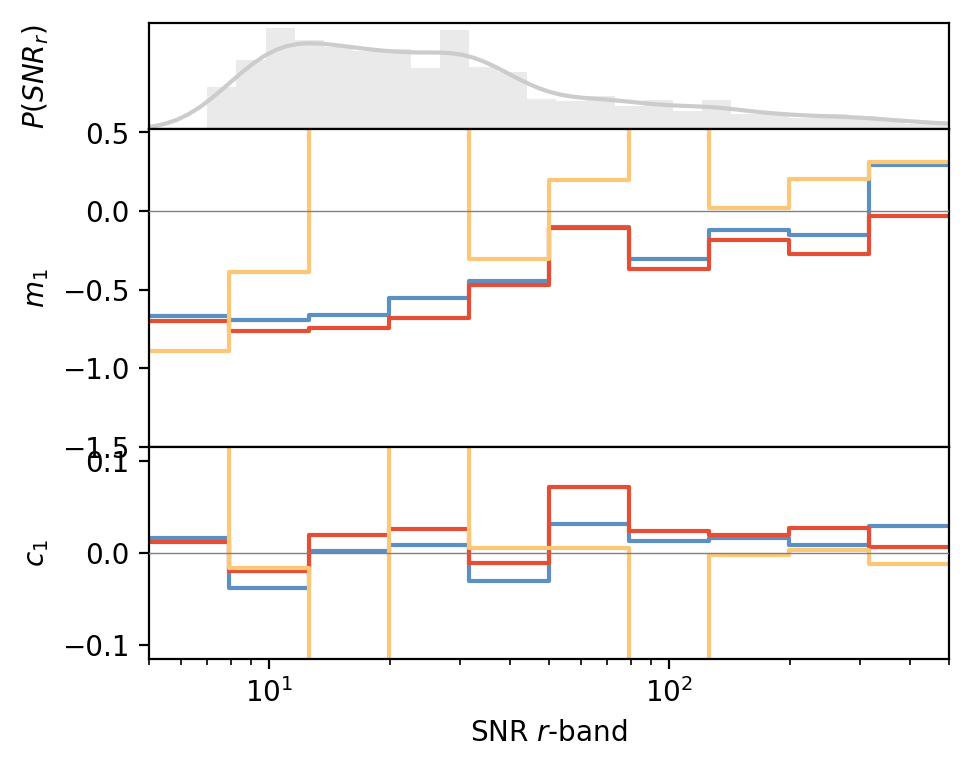

In [76]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (5, 500),
              ylim = (-1.5,0.52), 
              ylim2 = (-0.115, 0.115), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)

3516
[1 2 3]
0 1
1 2
2 3


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 3 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-

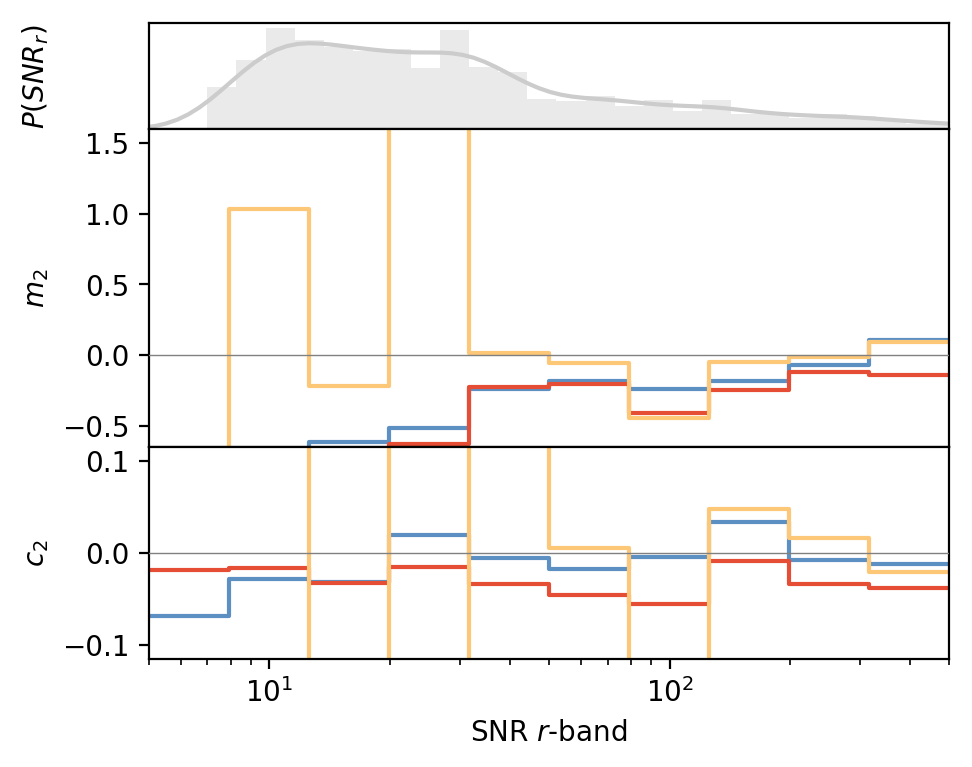

In [77]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e2_conv', y = 'e2_meas', z = 'exp', shear = 'shear_2',
              xlim = (5, 500),
              ylim = (-0.65,1.6), 
              ylim2 = (-0.115, 0.115), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_2$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_2$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)

3516
[1 2 3]
0 1
1 2
2 3


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  "aka-proxy-artists".format(orig_handle)
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/legend.py:798: UserWarning: Legend does not support 3 instances.
A proxy artist may be used instead.
See: http://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-

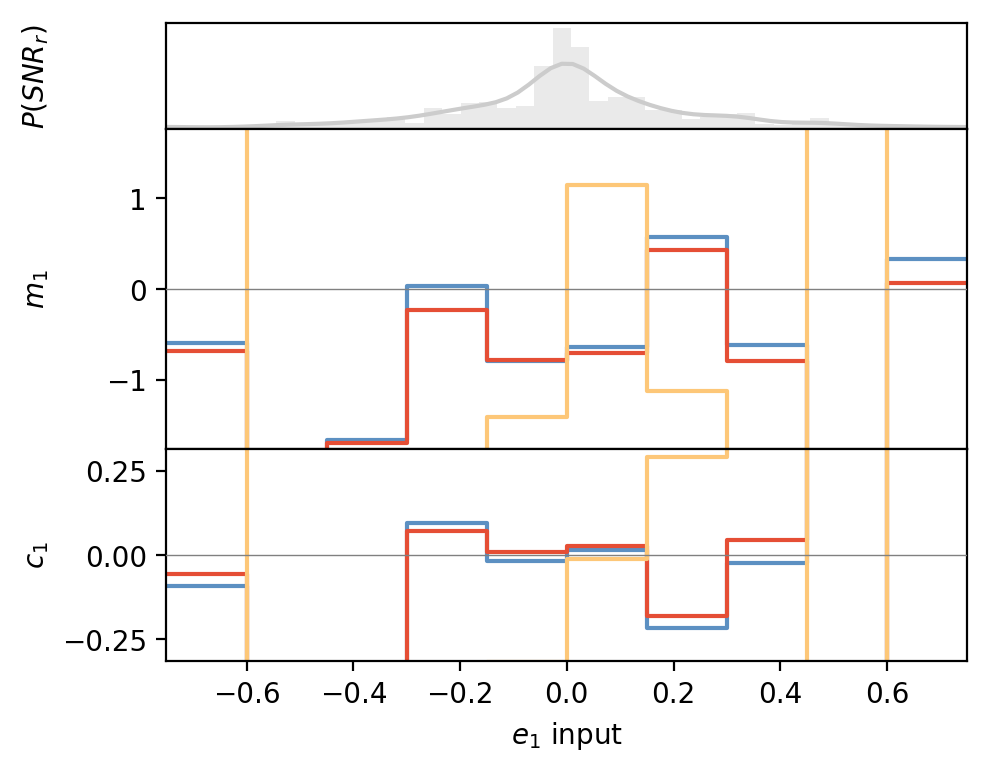

In [79]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'e1_conv', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (-0.75, 0.75),
              ylim = (-1.76,1.76), 
              ylim2 = (-0.315, 0.315), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'network cut 26.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15,.35]),#0.35,
              nbins = 10)